# Descriptive Statistics & Data Understanding #

In [ ]:
from datasets import load_dataset

ds = load_dataset("tarekmasryo/cancer-risk-factors-data")
df = ds["train"].to_pandas()

print(df.shape)
print(df.head())

In [ ]:
df.to_csv("data/cancer-risk-factors-data.csv", index=False)

In [2]:
df.shape

(2000, 21)

In [2]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("data/cancer-risk-factors-data.csv")

In [9]:
df.dtypes

Patient_ID                  object
Cancer_Type                 object
Age                          int64
Gender                       int64
Smoking                      int64
Alcohol_Use                  int64
Obesity                      int64
Family_History               int64
Diet_Red_Meat                int64
Diet_Salted_Processed        int64
Fruit_Veg_Intake             int64
Physical_Activity            int64
Air_Pollution                int64
Occupational_Hazards         int64
BRCA_Mutation                int64
H_Pylori_Infection           int64
Calcium_Intake               int64
Overall_Risk_Score         float64
BMI                        float64
Physical_Activity_Level      int64
Risk_Level                  object
dtype: object

In [13]:
age_mean = np.mean(df["Age"])
age_mean

63.248

In [24]:
age_median = np.median(df["Age"])
age_median

64.0

In [25]:
age_mode = df["Age"].mode()
age_mode

0    64
1    65
Name: Age, dtype: int64

In [27]:
min_age = df["Age"].min()
min_age

25

In [28]:
max_age = df["Age"].max()
max_age

90

In [30]:
age_range = df["Age"].max() - df["Age"].min()
age_range

65

## Quantiles and percentiles ##

25% quantile - mean that 25% of data point are below this values
75% quantile - mean that 75% of data point are below this values
Percentiles are basically the same, but we can technically split the data into 100 percentiles (even despite the fact that some datasets are too small).

In [ ]:
percentile_25 = np.percentile(df["Age"], 24)
percentile_25
# 56.0 -> 25% of rows on this dataset are less than 56 years old

56.0

In [ ]:
percentile_90 = np.percentile(df["Age"], 89)
percentile_90
# 76.0 -> 90% of rows on this dataset are less than 76 years old

76.0

### Histograms ###

Numeric data split into bins and displayed as bars. Can be used to predict the probability of future measurements. 

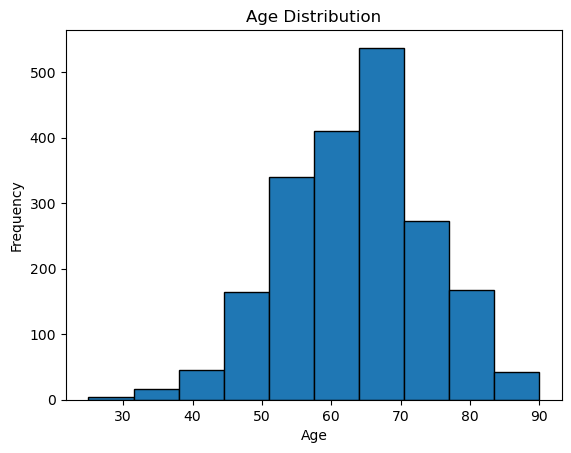

In [35]:
import matplotlib.pyplot as plt
plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


This first part is very well summarized here:
- [Measures of Central Location](https://saylordotorg.github.io/text_introductory-statistics/s06-02-measures-of-central-location.html)
- [Popular Data Displays](https://saylordotorg.github.io/text_introductory-statistics/s06-01-three-popular-data-displays.html)
- [Quantiles and Percentiles](https://youtu.be/IFKQLDmRK0Y?si=Nq-PXjBsqqMJMeWt)
- [Histograms](https://youtu.be/qBigTkBLU6g?si=6n73NpC6kbhT5K0n)

### The Variance and the Standard Deviation ###

In [ ]:
age_variance = df["Age"].var()
age_variance
# 109.47323261630808

109.47323261630808

Variance for sample and for whole population are different. 

Formula for sample variance: 

**Sample Variance:** 
# ![Sample Variance](images/sample_variance.png)

Basically, this is sum of each number minus mean (X with - on top) to the second power and divided by number of samples -1

In [ ]:
# manual calculation
mean = sum(df["Age"]) / len(df["Age"])
numerator = sum((df["Age"] - mean) ** 2)
denominator = len(df["Age"]) - 1
age_variance = numerator / denominator
age_variance
# 109.47323261630815

109.47323261630815

**Population Variance**

![Population Variance](images/population_variance.png)

In [ ]:
mean = sum(df["Age"]) / len(df["Age"])
numerator = sum((df["Age"] - mean) ** 2)
denominator = len(df["Age"])
age_variance = numerator / denominator
age_variance
# 109.418496 - slightly less than sample variance

109.418496

**Standart Deviation** - measures how spread out numbers in a dataset are from the average (mean); a low SD means data points cluster near the mean, while a high SD means they're widely dispersed

Standard deviation is calculated as square root of variance.

In [12]:
stdev_age = np.sqrt(age_variance)
stdev_age
#10.460329631517356

10.460329631517356

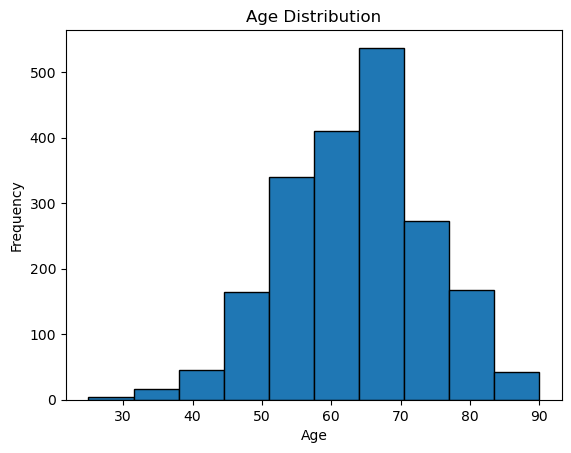

In [ ]:
# plot histogram of age
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


Text(0.5, 1.0, 'Age Distribution')

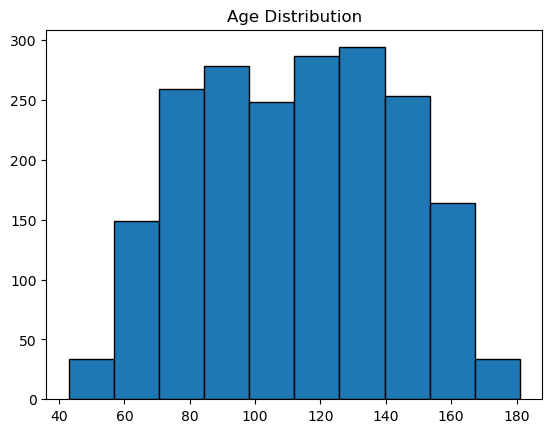

In [16]:
#now lets modify the data randomly 

age_modified = df["Age"] + np.random.randint(0, 100, size=len(df["Age"]))
age_modified
# plot histogram of age
import matplotlib.pyplot as plt

plt.hist(age_modified, bins=10, edgecolor="black")
plt.title("Age Distribution")

In [ ]:
age_stdev = np.std(df['Age'])
#10.46032963151735
age_stdev_modified = np.std(age_modified)
# 30.396687171466592

print(age_stdev)
print(age_stdev_modified)


10.46032963151735
30.396687171466592


Two values will have different standard deviations. First one has smaller standard deviation because values are closer to the mean. Second one has larger deviation because values are more widely dispersed.

### Interquartile Range ###

IQR is a difference between 75th and 25th quartiles

IQR=Q3−Q1

In [25]:
age_25th_percentile = np.percentile(df["Age"], 25)
age_75th_percentile = np.percentile(df["Age"], 75)
IQR = age_75th_percentile - age_25th_percentile
print("25th percentile:", age_25th_percentile)
print("75th percentile:", age_75th_percentile)
print("IQR:", IQR)
# 14.0

25th percentile: 56.0
75th percentile: 70.0
IQR: 14.0


Min, max, 25th percentile, 75th percentile, median can be observed on a boxplot. IQR is a box in a middle of a boxplot.

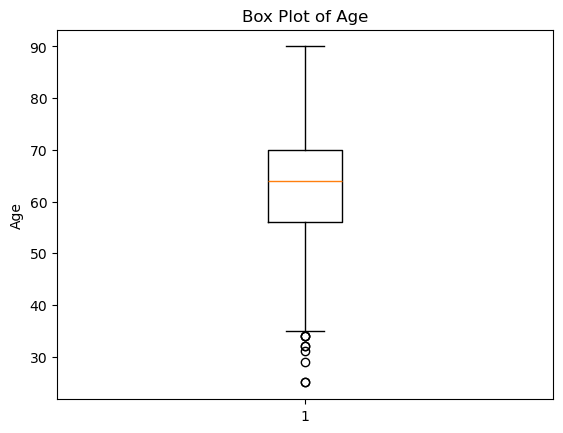

In [ ]:
# box plot
plt.boxplot(df['Age'], vert=True)
plt.title("Box Plot of Age")
plt.ylabel("Age")
plt.show()

### Z-score ###
It is a distance from the mean in units of standard deviation

0       0.454174
1       1.027626
2      -0.788306
3      -0.214853
4       0.358599
          ...   
1995   -0.310429
1996    1.983380
1997    0.167448
1998    0.071873
1999    0.071873
Name: Age, Length: 2000, dtype: float64


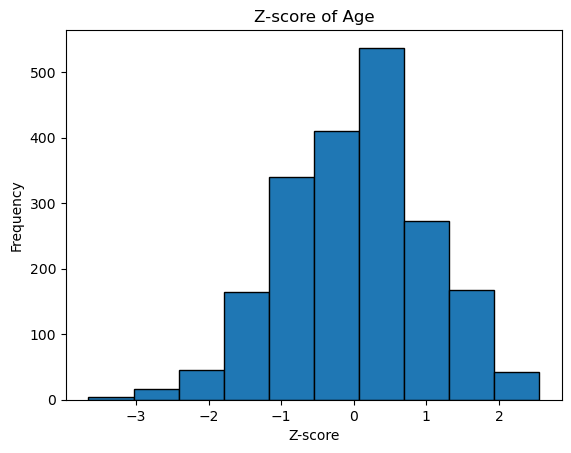

In [29]:
age_zscore = (df["Age"] - df["Age"].mean()) / df["Age"].std()
print(age_zscore)
# plot histogram of z-score
plt.hist(age_zscore, bins=10, edgecolor="black")
plt.title("Z-score of Age")
plt.xlabel("Z-score")
plt.ylabel("Frequency")
plt.show()



### Skewness and Kurtosis ###

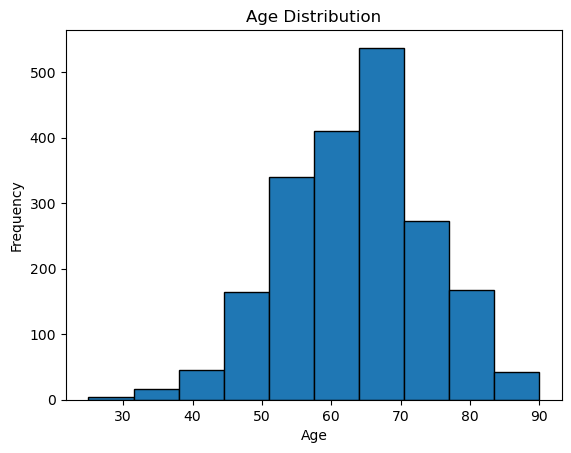

In [4]:
# plot histogram of age
import matplotlib.pyplot as plt

plt.hist(df["Age"], bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

This plot is normally distrubutet with a very small negative skewness of -0.071 - this falls in a range of normal skewness of [-3 ; 3] - Pearson's Coeficient of Skewness

In [ ]:
mean = np.mean(df["Age"])
median = np.median(df["Age"])
skewness = (mean - median) / np.std(df["Age"])
print(skewness)

-0.07189065990178735


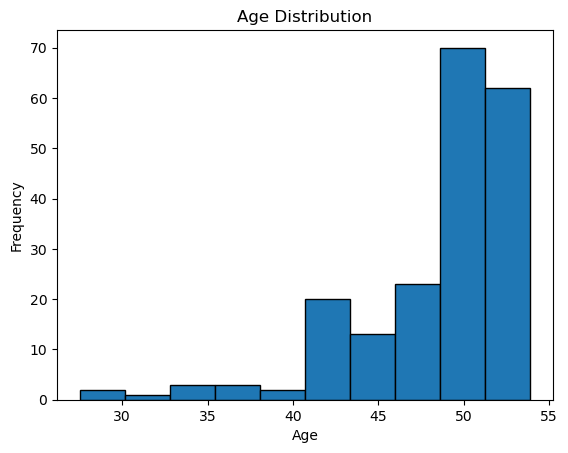

In [35]:
age_modified = [a * 1.1 for a in df["Age"] if a < 50] #
plt.hist(age_modified, bins=10, edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

This data was artificially modified. There is visible negative (left) skewness (mode > mean). The ratio is -0.2.

In [36]:
mean = np.mean(age_modified)
median = np.median(age_modified)
skewness = (mean - median) / np.std(age_modified)
print(skewness)

-0.20513608857789478


**Next steps:**
- qq plots